In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import Masking
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import random

In [ ]:
PATH = '/content/nezivi-viktoria-text.txt'

In [ ]:
text = ''
with open(PATH, mode='r') as f:
    text = f.read()


In [ ]:
text

'~ 1 ~ \n \n \n \n \n \n                 \n \n(Ne)Živí \n \n \n \n \n \n \n \n \n„Prečo sa snažíš zapadnúť, keď si sa narodil preto,             \naby si vyčnieval?“ \nT.S. Geisel \n~ 2 ~ \n~ 3 ~ \n \n \n \n \n \n \n    Mia \n \n \n \n \n \n \n \n \n \n \n                           \nKAPITOLA 1 \nPrečo musím každé ráno vstávať tak skoro? Oh, tá hlúpa \npráca. Nejako si však peniaze zarobiť musím. Veď práve \nteraz mám život o akom som vždy snívala, chcela som byť \nsamostatná, mať vlastný byt, prácu a nebyť od nikoho \nzávislá. Tak na čo sa sťažujem? Nakoniec tá výchova \nv detskom domove nebola až tak zlá. Vďaka tomu sa zo \nmňa stala silná, sebavedomá, odvážna žena.  \nČo si to navrávam? Pravda je, že zakaždým keď idem po \nmeste, otáčam sa po šťastných rodinkách, ktoré si užívajú \nspoločné chvíle a potichu im závidím. Ktovie aká by som \nbola ak by som vyrastala obklopená ľuďmi, ktorí by ma \nmali radi, vypočuli ma, utešovali a podporovali. O tom však \nmôžem len snívať. Tá diera v

### Preprocessing

In [ ]:
symbols = set()
for symbol in text:
    symbols.add(symbol)

In [ ]:
short_vowels = ('a', 'ä', 'e', 'i', 'y', 'o', 'u', 'ô')
long_vowels = ('á', 'é', 'í', 'ý', 'ó', 'ú')
filling = ' '
alphabet = (filling, 'a', 'á', 'ä', 'b', 'c', 'č', 'd', 'ď', 'e', 'é', 'f', 'g', 'h', 'i', 'í', 'j', 'k', 'l', 'ĺ', 'ľ', 'm', 'n', 'ň', 'o', 'ó',
'ô', 'p', 'q', 'r', 'ŕ', 's', 'š', 't', 'ť', 'u', 'ú', 'v', 'w', 'x', 'y', 'ý', 'z', 'ž')
higher_alphabet = tuple([letter.upper() for letter in alphabet if letter != filling])
consonants = tuple([sym for sym in alphabet if sym not in short_vowels and sym not in long_vowels])
number_labels = {letter:j for j, letter in enumerate(alphabet)}

In [ ]:
text_delimiters = ''
for symbol in symbols:
    if symbol not in [word for word in alphabet if word != ' '] and symbol not in higher_alphabet:
        text_delimiters += symbol
delimiters = {delim:' ' for delim in text_delimiters}
text = text.translate(str.maketrans(delimiters))
list_of_words = text.split()

In [ ]:
def which_letter(letter):
    if letter in short_vowels:
        return 'krátka samohláska'
    elif letter in long_vowels:
        return 'dlhá samohláska'
    elif letter in consonants:
        return 'spoluhláska'

In [ ]:
# slova, ktore maju aspon dlzku 2, neobsahuju x a su unikatne
clean_words = [w for w in list_of_words if len(w) > 1 and 'x' not in w]
clean_words = list(set([w.lower() for w in clean_words]))

In [ ]:
lengths = set()
for word in clean_words:
    length = len(word)
    lengths.add(length)

In [ ]:
random_indices = [random.randrange(0,len(word_helper)) for word_helper in clean_words]
random_letters = [w[idx] for idx, w in zip(random_indices, clean_words)]
random_letters = list(map(which_letter, random_letters))
words_with_x = []
max_length = max(lengths)
for i, idx in enumerate(random_indices):
    clean_word = clean_words[i]
    clean_word = clean_word[:idx] + 'x' + clean_word[idx+1:] + (max_length - len(clean_word)) * filling
    words_with_x.append(clean_word)

In [ ]:
from collections import Counter

counts = Counter(random_letters)
print(counts)
# mame velmi malo dlhych samohlasok --> treba vybalansovat dataset

Counter({'spoluhláska': 5309, 'krátka samohláska': 3233, 'dlhá samohláska': 534})


In [ ]:
target_cat_labels = {'krátka samohláska':0, 'dlhá samohláska':1, 'spoluhláska':2}
def target2label(target):
    return target_cat_labels[target]

In [ ]:
def word2vec(word):
    return [number_labels[char] for char in word]

In [ ]:
X = [word2vec(w_helper) for w_helper in words_with_x]
X = to_categorical(X, num_classes=len(alphabet))
y = list(map(target2label, random_letters))
y = to_categorical(y, num_classes=3)

In [ ]:
def make_zero_vec(M):
    for word in M:
        for letter_helper in word:
            # filling of holes is not considered to be a character -
            # thus it is zero vector - omitted in a process of
            if letter_helper[0] == 1:
                letter_helper[0] = 0.0

In [ ]:
# tu robim z jednotkovych vektorov nulove vtedy,
# ked je dane slovo len vyplnou (aby sa mohlo dane
# pismeno skipnut)
make_zero_vec(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [ ]:
# balancovanie datasetu
y_train_labels = np.argmax(y_train, axis=1)
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y_train_labels),y=y_train_labels)

In [ ]:
class_weights = dict(enumerate(class_weights))

### Modeling

In [ ]:
model = Sequential()
model.add(layers.InputLayer(shape=(None, len(alphabet))))
model.add(layers.Masking(mask_value=0.0)) # if all values of a vector are 0, then ignore the letter - it is a filling
model.add(layers.LSTM(64))
#model.add(layers.Dense(32, "relu"))
model.add(layers.Dense(3, "softmax"))

model.summary()

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_4 (Masking)             │ (None, None, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        27,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,099 (109.76 KB)

 Trainable params: 28,099 (109.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - acc: 0.2314 - loss: 1.1330 - val_acc: 0.6162 - val_loss: 0.9015
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.6349 - loss: 0.8789 - val_acc: 0.6673 - val_loss: 0.7090
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.6637 - loss: 0.7895 - val_acc: 0.7066 - val_loss: 0.6759
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.7043 - loss: 0.6996 - val_acc: 0.7830 - val_loss: 0.5005
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.7585 - loss: 0.6010 - val_acc: 0.7528 - val_loss: 0.5352
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - acc: 0.7647 - loss: 0.5844 - val_acc: 0.7106 - val_loss: 0.6110
Epoch 7/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 0.7713 - loss: 0.5390 - val_acc: 0.7830 - val_loss: 0.4830
Epoch 8/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.7981 - loss: 0.5060 - val_acc: 0.7429 - val_loss: 0.5540
Epoch 9/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_test_classes = np.argmax(y_test, axis=1)

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


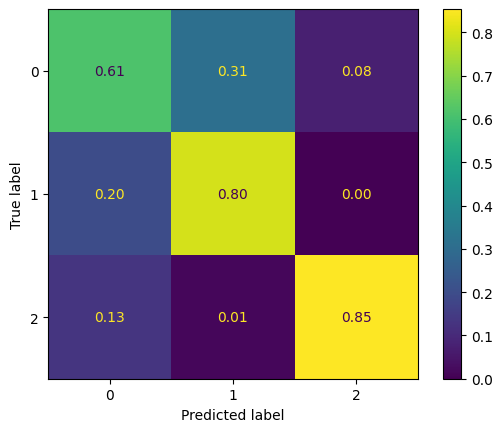

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_classes, y_pred_classes, normalize='true', values_format='.2f'
)
plt.show()

### Classification with input

In [ ]:
cat_pairs = [(key, target_cat_labels[key]) for key in target_cat_labels.keys()]
inverse_labels = {k:v for v,k in cat_pairs}

In [ ]:
print(f'Zadajte slovo (nie dlhsie ako {max(lengths)} znakov): ')
input_word = input()
input_word = input_word + (max_length - len(input_word)) * ' '
number_repr_word = word2vec(input_word)
number_repr_word = np.array(to_categorical(number_repr_word, num_classes=len(alphabet)))
number_repr_word = np.expand_dims(number_repr_word, axis=0)
make_zero_vec(number_repr_word)
predicted_category = model.predict(number_repr_word)
predicted_category = [k for k,v in target_cat_labels.items() if v == np.argmax(predicted_category)][0]
print('Správna odpoveď: ')
print('(zadajte len s možností: krátka samohláska, dlhá samohláska, spoluhláska)')
real_cat = input()
print(real_cat)
print(f'Predikcia: {predicted_category}')

Zadajte slovo (nie dlhsie ako 17 znakov): 
vixnoce
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Správna odpoveď: 
(zadajte len s možností: krátka samohláska, dlhá samohláska, spoluhláska)
krátka samohláska
krátka samohláska
Predikcia: krátka samohláska


### Effect of the size of test (train) size

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# learning NN on multiple possibilities of
# the size of test and train sizes of dataset
micro, weighted = dict(), dict()
start = 0.1
end = 0.9
precision = 0.1
while start < 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=start, stratify=y)
    # balancovanie datasetu
    y_train_labels = np.argmax(y_train, axis=1)
    class_weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y_train_labels),y=y_train_labels)
    class_weights = dict(enumerate(class_weights))
    model = Sequential()
    model.add(layers.InputLayer(shape=(None, len(alphabet))))
    model.add(layers.Masking(mask_value=0.0))
    model.add(layers.LSTM(64))
    model.add(layers.Dense(3, "softmax"))

    model.summary()

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_data=(X_test, y_test),
        class_weight=class_weights
    )

    y_test_classes = np.argmax(y_test, axis=1)
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    # computing micro and weighted F1 scores
    micro[start] = f1_score(y_test_classes, y_pred_classes, average='micro')
    weighted[start] = f1_score(y_test_classes, y_pred_classes, average='weighted')
    start = round(start + precision, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_5 (Masking)             │ (None, None, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        27,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,099 (109.76 KB)

 Trainable params: 28,099 (109.76 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_13 (Masking)            │ (None, None, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        27,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,099 (109.76 KB)

 Trainable params: 28,099 (109.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - acc: 0.3475 - loss: 1.1072 - val_acc: 0.4675 - val_loss: 1.0852
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - acc: 0.5792 - loss: 1.0556 - val_acc: 0.5540 - val_loss: 1.0595
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.6304 - loss: 1.0415 - val_acc: 0.5627 - val_loss: 1.0142
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - acc: 0.5783 - loss: 1.0049 - val_acc: 0.5906 - val_loss: 0.9342
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - acc: 0.6374 - loss: 0.9028 - val_acc: 0.5670 - val_loss: 0.9046
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - acc: 0.5920 - loss: 0.8493 - val_acc: 0.5467 - val_loss: 0.9516
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.6461 - loss: 0.7950 - val_acc: 0.5685 - val_loss: 0.9048
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.6378 - loss: 0.7735 - val_acc: 0.5968 - val_loss: 0.8572
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.67

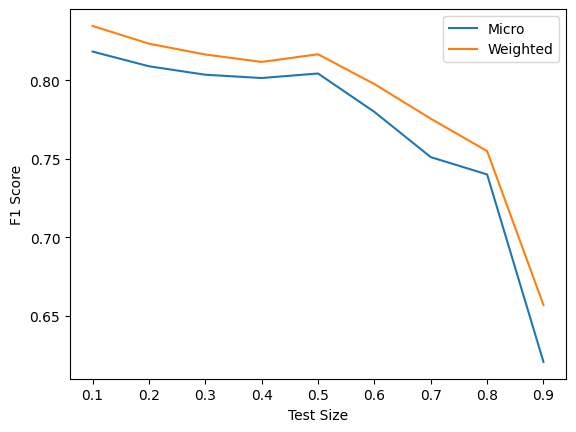

In [ ]:
# cim vyssie F1 skóre, tým lepšie
plt.plot(sorted(list(micro.keys())), [micro[val] for val in sorted(list(micro.keys()))])
plt.plot(sorted(list(weighted.keys())), [weighted[val] for val in sorted(list(weighted.keys()))])
plt.xlabel('Test Size')
plt.ylabel('F1 Score')
plt.legend(['Micro', 'Weighted'])
plt.show()